In [ ]:
#importing basic libraries for EDA AND ANALYSIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#importing our library for data preprocessing and dataspliting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#importing our ML model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


#importing our evaluation metric for measuring model performace
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curvel

In [99]:
#reading the dataset
df = pd.read_csv(r"C:\Users\Ghosts\Downloads\loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [100]:
#CHECKING THE SHAPE OF OUR DATASET
df_shape = df.shape
print(df_shape)

(45000, 14)


In [101]:
# Check info and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [137]:
# Statistical summary for numerical columns
print(df.describe())




         person_age  person_gender  person_income  person_emp_exp  \
count  45000.000000   45000.000000   4.500000e+04    45000.000000   
mean      27.764178       0.552022   8.031905e+04        5.410333   
std        6.045108       0.497292   8.042250e+04        6.063532   
min       20.000000       0.000000   8.000000e+03        0.000000   
25%       24.000000       0.000000   4.720400e+04        1.000000   
50%       26.000000       1.000000   6.704800e+04        4.000000   
75%       30.000000       1.000000   9.578925e+04        8.000000   
max      144.000000       1.000000   7.200766e+06      125.000000   

          loan_amnt  loan_int_rate  loan_percent_income  \
count  45000.000000   45000.000000         45000.000000   
mean    9583.157556      11.006606             0.139725   
std     6314.886691       2.978808             0.087212   
min      500.000000       5.420000             0.000000   
25%     5000.000000       8.590000             0.070000   
50%     8000.000000     

In [138]:
# Frequency counts for categorical columns
print(df['person_age'].value_counts())
print(df['person_income'].value_counts())

person_age
23.0     5254
24.0     5138
25.0     4507
22.0     4236
26.0     3659
27.0     3095
28.0     2728
29.0     2455
30.0     2021
31.0     1645
32.0     1403
21.0     1289
33.0     1240
34.0      980
35.0      847
36.0      740
37.0      666
38.0      503
39.0      389
40.0      349
41.0      303
42.0      247
43.0      215
44.0      177
45.0      135
46.0      114
47.0      112
48.0       93
49.0       59
50.0       56
51.0       46
52.0       42
53.0       35
55.0       24
54.0       24
58.0       20
56.0       20
57.0       17
20.0       17
60.0       16
61.0       12
66.0       11
65.0       10
62.0        7
70.0        7
64.0        7
59.0        6
69.0        5
73.0        3
144.0       3
63.0        3
123.0       2
78.0        1
94.0        1
80.0        1
84.0        1
76.0        1
67.0        1
116.0       1
109.0       1
Name: count, dtype: int64
person_income
8000.0     15
73011.0    10
36995.0     9
37020.0     8
60914.0     8
           ..
16720.0     1
29547.0    

In [139]:
print("Median:\n", df.median())
print("Variance:\n", df.var())
print("Skewness:\n", df.skew())

Median:
 person_age                           26.00
person_gender                         1.00
person_income                     67048.00
person_emp_exp                        4.00
loan_amnt                          8000.00
loan_int_rate                        11.01
loan_percent_income                   0.12
cb_person_cred_hist_length            4.00
credit_score                        640.00
previous_loan_defaults_on_file        1.00
loan_status                           0.00
person_education_Bachelor             0.00
person_education_Doctorate            0.00
person_education_High School          0.00
person_education_Master               0.00
person_home_ownership_OTHER           0.00
person_home_ownership_OWN             0.00
person_home_ownership_RENT            1.00
loan_intent_EDUCATION                 0.00
loan_intent_HOMEIMPROVEMENT           0.00
loan_intent_MEDICAL                   0.00
loan_intent_PERSONAL                  0.00
loan_intent_VENTURE                   0.00
dt

In [102]:
# Binary columns: Yes/No → 1/0
binary_cols = ['person_gender','previous_loan_defaults_on_file',]
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0, 'male':1,'female':0})

# Remaining categorical columns → One-Hot Encoding
categorical_cols = ['person_education','person_home_ownership','loan_intent']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ---- 3. Ensure boolean columns are treated as numeric (optional) ----
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [103]:
df.head(10)

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,0,1,0,0,1,0,0,0,1,0
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,1,0,0,1,0,1,0,0,0,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,...,0,0,0,0,1,0,0,1,0,0
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,...,0,1,0,0,1,0,0,1,0,0
5,21.0,0,12951.0,0,2500.0,7.14,0.19,2.0,532,0,...,1,0,0,1,0,0,0,0,0,1
6,26.0,0,93471.0,1,35000.0,12.42,0.37,3.0,701,0,...,0,0,0,0,1,1,0,0,0,0
7,24.0,0,95550.0,5,35000.0,11.11,0.37,4.0,585,0,...,1,0,0,0,1,0,0,1,0,0
8,24.0,0,100684.0,3,35000.0,8.90,0.35,2.0,544,0,...,0,0,0,0,1,0,0,0,1,0
9,21.0,0,12739.0,0,1600.0,14.74,0.13,3.0,640,0,...,1,0,0,1,0,0,0,0,0,1


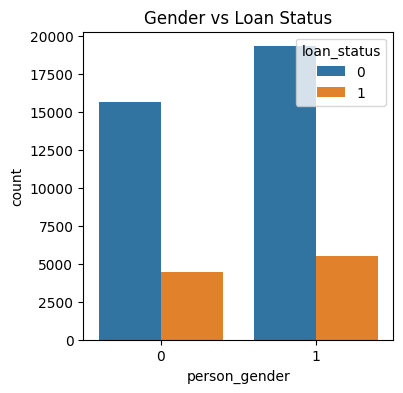

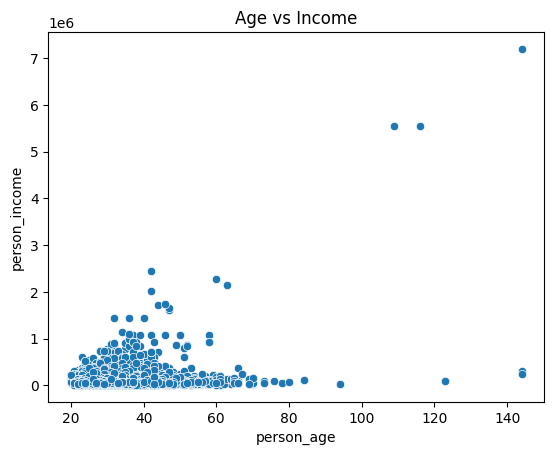

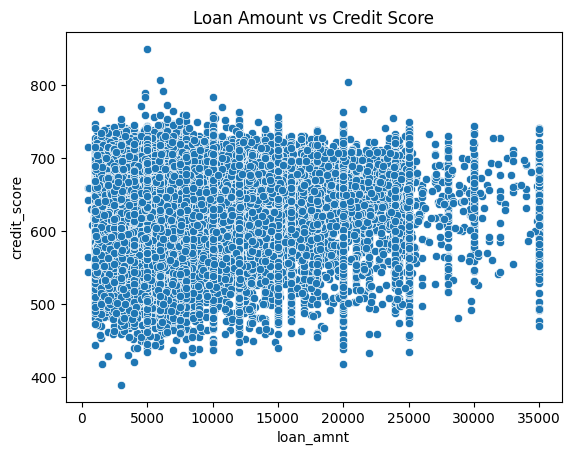

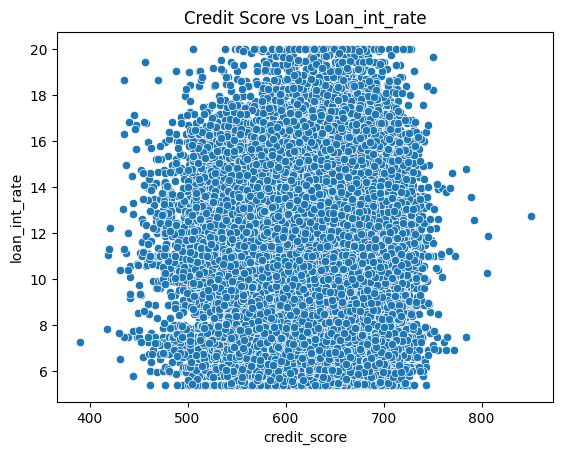

In [104]:
plt.figure(figsize = (4 , 4))
sns.countplot(x='person_gender', hue='loan_status', data=df)
plt.title("Gender vs Loan Status")
plt.xticks(rotation=0)
plt.show()

plt.figure()
sns.scatterplot(x="person_age", y="person_income", data=df)
plt.title("Age vs Income")
plt.show()

plt.figure()
sns.scatterplot(x="loan_amnt", y="credit_score", data=df)
plt.title("Loan Amount vs Credit Score")
plt.show()

plt.figure()
sns.scatterplot(x="credit_score", y="loan_int_rate", data=df)
plt.title("Credit Score vs Loan_int_rate")
plt.show()



In [105]:
# Target variable
y = df['loan_status']
X = df.drop(columns=['loan_status'])


# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [106]:
target_col = "loan_status"

print("Target distribution:\n", df[target_col].value_counts())
print("\nTarget %:\n", (df[target_col].value_counts(normalize=True) * 100).round(2))

Target distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64

Target %:
 loan_status
0    77.78
1    22.22
Name: proportion, dtype: float64


In [107]:
print("X_train" , X_train.shape)
print("y_train" , y_train.shape )

X_train (36000, 22)
y_train (36000,)


In [108]:
print("BEFORE SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))


BEFORE SMOTE:
loan_status
0    28000
1     8000
Name: count, dtype: int64
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['loan_int_rate','loan_percent_income','cb_person_cred_hist_length','credit_score', 'person_income', 'person_age']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [109]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [110]:

print("After SMOTE:")
print(y_train_resampled.value_counts())
print(y_train_resampled.value_counts(normalize=True))

After SMOTE:
loan_status
0    28000
1    28000
Name: count, dtype: int64
loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64


In [111]:
print("X_train" , X_train.shape)
print("y_train" , y_train.shape )

X_train (36000, 22)
y_train (36000,)


In [112]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

def evaluate_classifier(model, X_test, y_test, name="Model"):
    """
    Evaluates a classifier and returns a dictionary of metrics.
    Assumes model supports predict() and predict_proba().
    """
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (malignant)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba)
    }

    print(f"\n================ {name} ================")
    print("Accuracy :", round(metrics["accuracy"], 4))
    print("Precision:", round(metrics["precision"], 4))
    print("Recall   :", round(metrics["recall"], 4))
    print("F1-score :", round(metrics["f1"], 4))
    print("ROC-AUC  :", round(metrics["roc_auc"], 4))
    print("\nClassification report:\n", classification_report(y_test, pred))

    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return metrics


================ Logistic Regression ================
Accuracy : 0.8817
Precision: 0.7004
Recall   : 0.817
F1-score : 0.7542
ROC-AUC  : 0.9482

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92      7000
           1       0.70      0.82      0.75      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.86      0.84      9000
weighted avg       0.89      0.88      0.88      9000



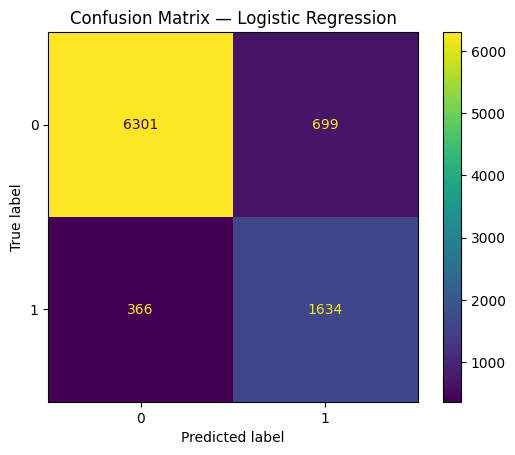

In [113]:
#  Logistic Regression Pipeline
# - median imputation
# - standard scaling
# - logistic regression

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

logreg.fit(X_train_resampled, y_train_resampled)
m_logreg = evaluate_classifier(logreg, X_test, y_test, name="Logistic Regression")

c:\Users\Ghosts\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Score: 0.9731380612244898

================ Logistic Regression (Tuned) ================
Accuracy : 0.8818
Precision: 0.7007
Recall   : 0.817
F1-score : 0.7544
ROC-AUC  : 0.9482

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92      7000
           1       0.70      0.82      0.75      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.86      0.84      9000
weighted avg       0.89      0.88      0.88      9000



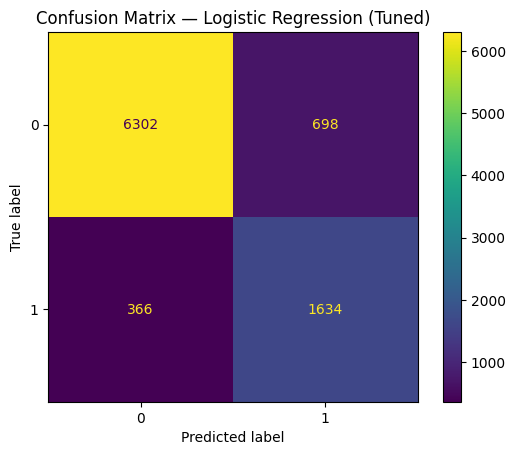

In [114]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]  # supports both l1 and l2
}

# Apply GridSearchCV
grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # better than accuracy for imbalance
    n_jobs=-1
)

# Fit GridSearch
grid.fit(X_train_resampled, y_train_resampled)

# Best model
best_logreg = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# Evaluate using your existing function
m_logreg = evaluate_classifier(best_logreg, X_test, y_test, name="Logistic Regression (Tuned)")


================ KNN (k=5) ================
Accuracy : 0.8793
Precision: 0.7075
Recall   : 0.779
F1-score : 0.7416
ROC-AUC  : 0.9225

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92      7000
           1       0.71      0.78      0.74      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.84      0.83      9000
weighted avg       0.88      0.88      0.88      9000



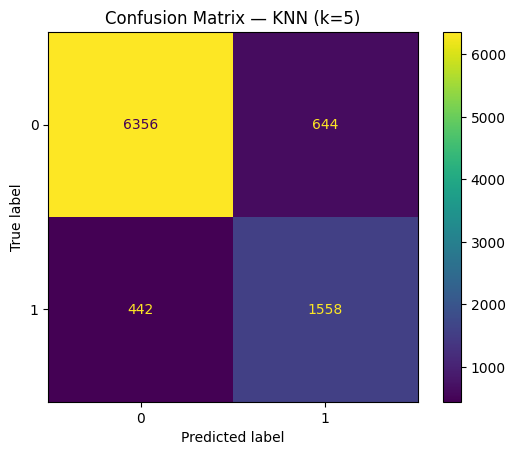

In [115]:
#  KNN Pipeline 

from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train_resampled, y_train_resampled)
m_knn = evaluate_classifier(knn, X_test, y_test, name="KNN (k=5)")

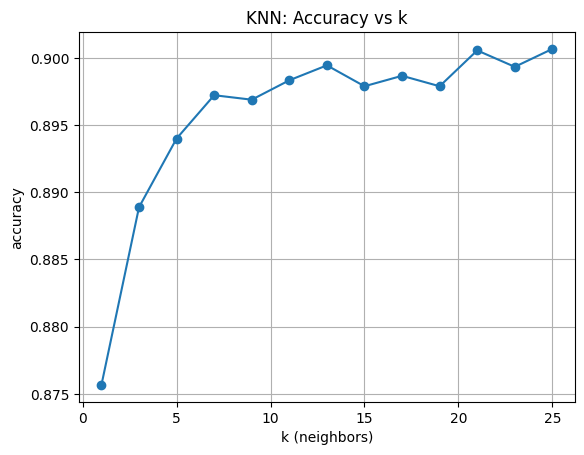

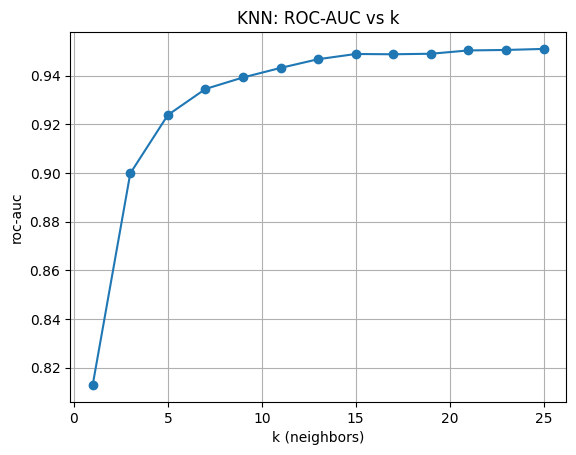

Best k by ROC-AUC: 25


In [117]:
#  KNN "manual tuning" over k

ks = list(range(1, 26, 2))
accs = []
aucs = []

for k in ks:
    tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    tmp.fit(X_train, y_train)
    pred = tmp.predict(X_test)
    proba = tmp.predict_proba(X_test)[:, 1]
    accs.append(accuracy_score(y_test, pred))
    aucs.append(roc_auc_score(y_test, proba))

plt.figure()
plt.plot(ks, accs, marker="o")
plt.title("KNN: Accuracy vs k")
plt.xlabel("k (neighbors)")
plt.ylabel("accuracy")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ks, aucs, marker="o")
plt.title("KNN: ROC-AUC vs k")
plt.xlabel("k (neighbors)")
plt.ylabel("roc-auc")
plt.grid(True)
plt.show()

best_k = ks[int(np.argmax(aucs))]
print("Best k by ROC-AUC:", best_k)


================ KNN (best k=25) ================
Accuracy : 0.8768
Precision: 0.6993
Recall   : 0.7815
F1-score : 0.7381
ROC-AUC  : 0.9397

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      7000
           1       0.70      0.78      0.74      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.84      0.83      9000
weighted avg       0.88      0.88      0.88      9000



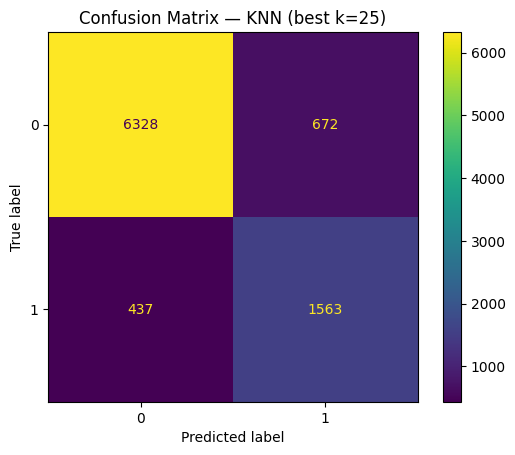

In [118]:
#  Train KNN with best_k

knn_best = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

knn_best.fit(X_train_resampled, y_train_resampled)
m_knn_best = evaluate_classifier(knn_best, X_test, y_test, name=f"KNN (best k={best_k})")


================ Decision Tree (default) ================
Accuracy : 0.8907
Precision: 0.735
Recall   : 0.7945
F1-score : 0.7636
ROC-AUC  : 0.8563

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      7000
           1       0.73      0.79      0.76      2000

    accuracy                           0.89      9000
   macro avg       0.84      0.86      0.85      9000
weighted avg       0.89      0.89      0.89      9000



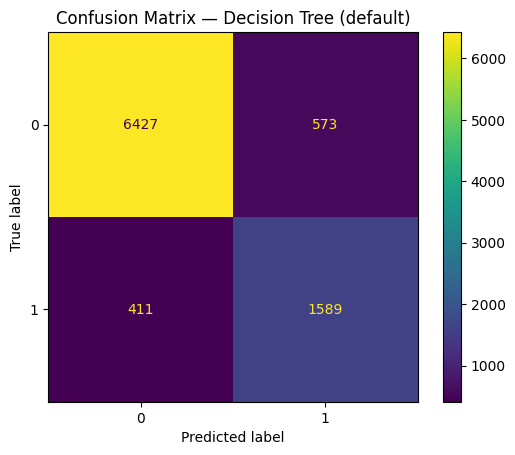

In [119]:
# Decision Tree 

from sklearn.tree import DecisionTreeClassifier

dt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt.fit(X_train_resampled, y_train_resampled)
m_dt = evaluate_classifier(dt, X_test, y_test, name="Decision Tree (default)")

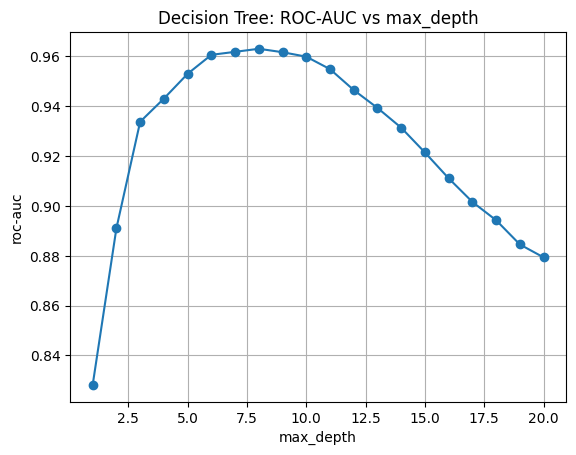

Best max_depth by ROC-AUC: 8


In [120]:
#  Decision Tree: control overfitting 

depths = list(range(1, 21))
auc_depth = []

for d in depths:
    tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    tmp.fit(X_train, y_train)
    proba = tmp.predict_proba(X_test)[:, 1]
    auc_depth.append(roc_auc_score(y_test, proba))

plt.figure()
plt.plot(depths, auc_depth, marker="o")
plt.title("Decision Tree: ROC-AUC vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("roc-auc")
plt.grid(True)
plt.show()

best_depth = depths[int(np.argmax(auc_depth))]
print("Best max_depth by ROC-AUC:", best_depth)


================ Decision Tree (best depth=8) ================
Accuracy : 0.8739
Precision: 0.6654
Recall   : 0.87
F1-score : 0.7541
ROC-AUC  : 0.9572

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92      7000
           1       0.67      0.87      0.75      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.87      0.83      9000
weighted avg       0.89      0.87      0.88      9000



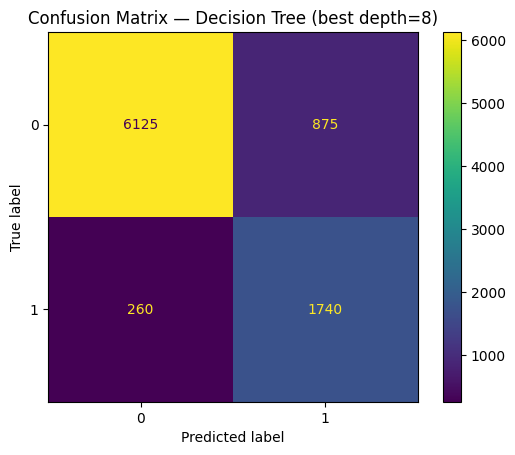

In [121]:
#  Decision Tree with best_depth

dt_best = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(max_depth=best_depth, random_state=42))
])

dt_best.fit(X_train_resampled, y_train_resampled)
m_dt_best = evaluate_classifier(dt_best, X_test, y_test, name=f"Decision Tree (best depth={best_depth})")


================ Random Forest (300 trees) ================
Accuracy : 0.9197
Precision: 0.8131
Recall   : 0.829
F1-score : 0.821
ROC-AUC  : 0.9712

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.81      0.83      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.88      9000
weighted avg       0.92      0.92      0.92      9000



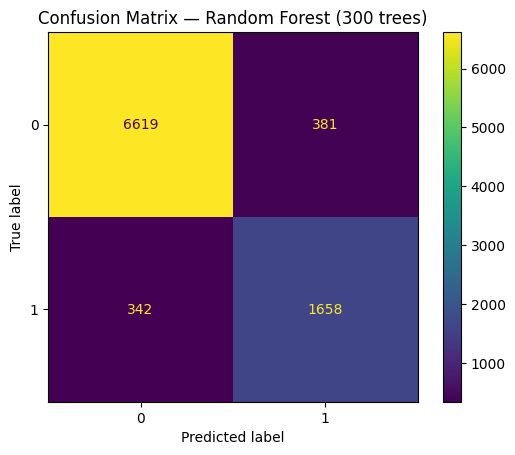

In [122]:
# Random Forest 

from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train_resampled, y_train_resampled)
m_rf = evaluate_classifier(rf, X_test, y_test, name="Random Forest (300 trees)")

In [123]:
#Random Forest tuning (n_estimators + max_depth)
n_estimators_list = [100, 200, 400]
max_depth_list = [None, 3, 5, 8, 12]

best_auc = -1
best_params = None

for n in n_estimators_list:
    for d in max_depth_list:
        tmp = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=n,
                max_depth=d,
                random_state=42,
                n_jobs=-1
            ))
        ])
        tmp.fit(X_train, y_train)
        proba = tmp.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)

        if auc > best_auc:
            best_auc = auc
            best_params = (n, d)

print("Best RF params (n_estimators, max_depth):", best_params)
print("Best RF ROC-AUC:", round(best_auc, 4))

Best RF params (n_estimators, max_depth): (400, None)
Best RF ROC-AUC: 0.9758



================ Random Forest (best n=400, depth=None) ================
Accuracy : 0.9209
Precision: 0.8151
Recall   : 0.833
F1-score : 0.8239
ROC-AUC  : 0.9714

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.82      0.83      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.89      9000
weighted avg       0.92      0.92      0.92      9000



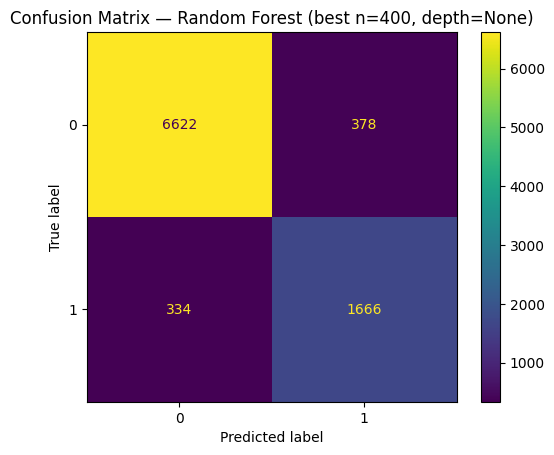

In [124]:
best_n, best_d = best_params  

rf_best = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=best_n,
        max_depth=best_d,
        random_state=42,
        n_jobs=-1
    ))
])

rf_best.fit(X_train_resampled, y_train_resampled)  
m_rf_best = evaluate_classifier(rf_best, X_test, y_test, name=f"Random Forest (best n={best_n}, depth={best_d})")

In [125]:
# -----------------------------
# Cell 19: Results comparison table
# -----------------------------
results = pd.DataFrame([
    m_logreg,
    m_knn,
    m_knn_best,
    m_dt,
    m_dt_best,
    m_rf,
    m_rf_best
]).sort_values(["roc_auc", "accuracy"], ascending=False)

results

,model,accuracy,precision,recall,f1,roc_auc
6,"Random Forest (best n=400, depth=None)",0.920889,0.815068,0.8330,0.823937,0.971395
5,Random Forest (300 trees),0.919667,0.813144,0.8290,0.820995,0.971191
4,Decision Tree (best depth=8),0.873889,0.665392,0.8700,0.754063,0.957162
0,Logistic Regression (Tuned),0.881778,0.700686,0.8170,0.754386,0.948172
2,KNN (best k=25),0.876778,0.699329,0.7815,0.738135,0.939737
1,KNN (k=5),0.879333,0.707539,0.7790,0.741552,0.922455
3,Decision Tree (default),0.890667,0.734968,0.7945,0.763575,0.856321


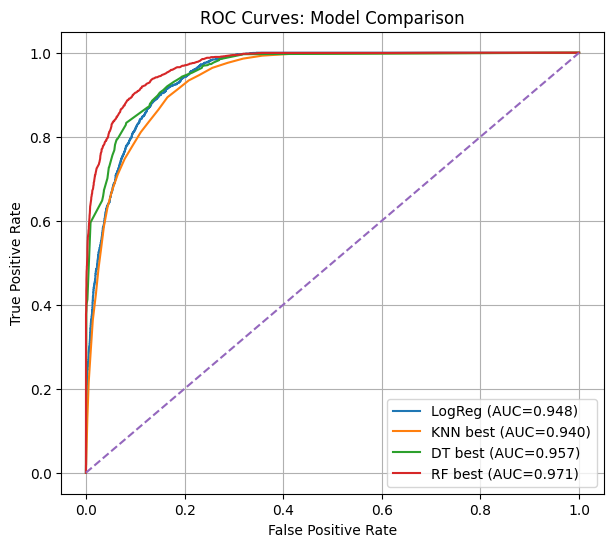

In [126]:
# Cell 20: Plot ROC curves for key models

from sklearn.metrics import roc_curve

def get_scores(model):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    return fpr, tpr, auc

plt.figure(figsize=(7, 6))

for model, name in [
    (logreg, "LogReg"),
    (knn_best, "KNN best"),
    (dt_best, "DT best"),
    (rf_best, "RF best"),
]:
    fpr, tpr, auc = get_scores(model)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves: Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
print("Train Accuracy:", best_logreg.score(X_train_resampled, y_train_resampled))
print("Test Accuracy:", best_logreg.score(X_test, y_test))

Train Accuracy: 0.9133392857142857
Test Accuracy: 0.8817777777777778
